In [1]:
import pandas as pd
import numpy as np
import os
import openpyxl
import matplotlib.pyplot as plt

# Load data

In [2]:
input_dir = "/mnt/c/users/helen/Desktop/010726"

In [17]:

dfs = []

for root, dirs, files in os.walk(input_dir):
    for filename in files:
        if filename.lower().endswith(".csv"):

            path = os.path.join(root, filename)

            df = pd.read_csv(path)

            # Optional metadata
            df["File"] = os.path.splitext(filename)[0].replace(" ", "_")
            df["Path"] = path

            dfs.append(df) 

# Combine all tables
data = pd.concat(dfs, ignore_index=True)

# Create ROI column
data['ROI'] = data['Label'].apply(lambda x: x.split(":")[1])
data['Sample_name'] = data['File'].apply(lambda x: x.split("_")[1].split("-")[0])

# Delete first 3 columns
data.drop(data.columns[[0, 1, 2]], axis=1, inplace=True)

# Reorder columns
data = data[
    [
        "Sample_name",
        "File",
        "Measurement_type",
        "Length",
        "ROI",
        "Path"
    ]
]

# Split data into 2 dataframes
speed = data[data['Measurement_type']=='Fiber_length']
iod = data[data['Measurement_type']=='Interorigin_distance']

# Process replication speed

In [19]:
conversion_factor = 2.59 # kb/µm
time = 20 # minutes

In [20]:
# Checking speed file
counts = speed.groupby("File").size()
odd_files = counts[counts % 2 != 0].index.tolist()

if len(odd_files) == 0:
    print("All files contain an even number of fibers.")
else:
    print("The following files contain an odd number of fibers will be removed:")
    print(*odd_files, sep="\n")
    
    # Removing odd files from speed dataframe
    speed = speed[~speed["File"].isin(odd_files)].copy()

The following files contain an odd number of fibers will be removed:
siORC1_MGS2-03_Fiber_length
siORC1_MGS4_Fiber_length


In [ ]:
# Add extra inedex to group pairs of files
speed["Index"] = speed.groupby("File").cumcount() // 2

# Calculate sum of fiber length in pairs
speed_processed = speed.groupby(["File", "Index"], as_index=False).agg(
        Total_Length=("Length", "sum"),
        ROI=("ROI", list),
        Path=("Path", "first"),
        Sample_name=("Sample_name", "first")
        )

# Convert speed to kb/min
speed_processed['Speed_kb_min'] = speed_processed['Total_Length'].apply(lambda x: x * conversion_factor / time)

# Delete extra columns
replication_speed = speed_processed[['Sample_name', 'File', 'Speed_kb_min', 'ROI', 'Path']]

# Info
n_fibers = len(replication_speed)
print(f"The amount of fibers is: {n_fibers}")

The amount of fibers is: 241


In [24]:
replication_speed

,File,Speed_kb_min,ROI,Path
0,siORC1_MGS1-02_Fiber_length,11.436145,"[0303-0404, 0273-0360]",/mnt/c/users/helen/Desktop/010726/siORC1_MGS1-...
1,siORC1_MGS1-03_Fiber_length,15.963594,"[0944-0253, 0968-0321]",/mnt/c/users/helen/Desktop/010726/siORC1_MGS1-...
2,siORC1_MGS1-03_Fiber_length,24.318417,"[0581-0161, 0525-0083]",/mnt/c/users/helen/Desktop/010726/siORC1_MGS1-...
3,siORC1_MGS1-04_Fiber_length,15.659917,"[0312-0882, 0342-0824]",/mnt/c/users/helen/Desktop/010726/siORC1_MGS1-...
4,siORC1_MGS1-04_Fiber_length,15.992473,"[0411-0686, 0381-0747]",/mnt/c/users/helen/Desktop/010726/siORC1_MGS1-...
...,...,...,...,...
236,siORC1_WT_Fiber_length,13.637256,"[0855-0428, 0827-0478]",/mnt/c/users/helen/Desktop/010726/siORC1_WT/si...
237,siORC1_WT_Fiber_length,14.576002,"[0928-0280, 0911-0341]",/mnt/c/users/helen/Desktop/010726/siORC1_WT/si...
238,siORC1_WT_Fiber_length,16.982501,"[0943-0076, 0935-0147]",/mnt/c/users/helen/Desktop/010726/siORC1_WT/si...
239,siORC1_WT_Fiber_length,9.898203,"[0735-0361, 0748-0324]",/mnt/c/users/helen/Desktop/010726/siORC1_WT/si...


In [16]:
replication_speed['File'].apply(lambda x: x.split("_")[1].split("-")[0])

0      MGS1
1      MGS1
2      MGS1
3      MGS1
4      MGS1
       ... 
236      WT
237      WT
238      WT
239      WT
240      WT
Name: File, Length: 241, dtype: str

# Process IOD

In [9]:
iod['IOD_kb'] = iod['Length'].apply(lambda x: x * conversion_factor)
iod_kb = iod[["File", 'IOD_kb', 'ROI', 'Path']]

# Info
n_origins = len(iod_kb)
print(f"The amount of origins is: {n_origins}")

The amount of origins is: 178


In [10]:
iod_kb

,File,IOD_kb,ROI,Path
18,siORC1_MGS1-04_Interorigin_distance,324.78341,0550-0404,/mnt/c/users/helen/Desktop/010726/siORC1_MGS1-...
19,siORC1_MGS1-04_Interorigin_distance,444.76516,0477-0521,/mnt/c/users/helen/Desktop/010726/siORC1_MGS1-...
20,siORC1_MGS1-04_Interorigin_distance,252.64414,0646-0786,/mnt/c/users/helen/Desktop/010726/siORC1_MGS1-...
27,siORC1_MGS1-07_Interorigin_distance,275.31959,0493-0678,/mnt/c/users/helen/Desktop/010726/siORC1_MGS1-...
28,siORC1_MGS1-07_Interorigin_distance,600.92921,0814-0659,/mnt/c/users/helen/Desktop/010726/siORC1_MGS1-...
...,...,...,...,...
651,siORC1_WT-07_Interorigin_distance,338.36278,0057-0319,/mnt/c/users/helen/Desktop/010726/siORC1_WT-07...
654,siORC1_WT-09_Interorigin_distance,322.44205,0317-0249,/mnt/c/users/helen/Desktop/010726/siORC1_WT-09...
655,siORC1_WT-09_Interorigin_distance,306.59384,0419-0180,/mnt/c/users/helen/Desktop/010726/siORC1_WT-09...
656,siORC1_WT-10_Interorigin_distance,639.16279,0332-1186,/mnt/c/users/helen/Desktop/010726/siORC1_WT-10...


# Graphs

## Replication speed graph

Plot is saved in the directory: /mnt/c/users/helen/Desktop/010726


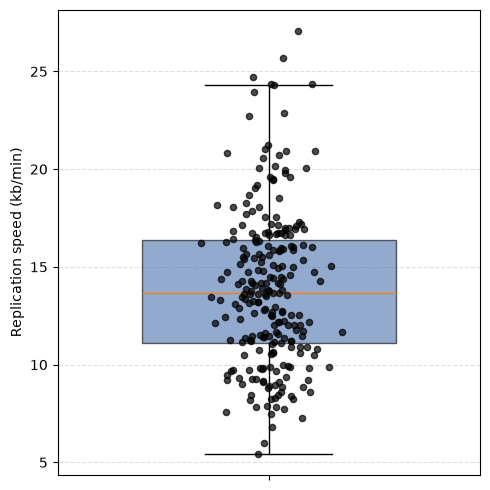

In [11]:
plt.figure(figsize=(5, 5))

values = replication_speed["Speed_kb_min"]

bp = plt.boxplot(
    values,
    patch_artist=True,
    showfliers=False,
    widths=0.6,
)

for box in bp["boxes"]:
    box.set(facecolor="#4C72B0", alpha=0.6)

# Jittered dots
x = np.random.normal(1, 0.05, len(values))
plt.scatter(x, values, s=20, color="black", alpha=0.7, zorder=3)

plt.ylabel("Replication speed (kb/min)")
plt.xticks([1], [""])
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(f"{input_dir}/replication_speed_boxplot.png", dpi=600, bbox_inches="tight")
print(f"Plot is saved in the directory: {input_dir}")

plt.show()

## IOD graph

In [ ]:
plt.figure(figsize=(5, 5))

values = iod_kb["IOD_kb"]

bp = plt.boxplot(
    values,
    patch_artist=True,
    showfliers=False,
    widths=0.6,
)

for box in bp["boxes"]:
    box.set(facecolor="#DD8452", alpha=0.6)

# Jittered dots
x = np.random.normal(1, 0.05, len(values))
plt.scatter(x, values, s=20, color="black", alpha=0.7, zorder=3)

plt.ylabel("IOD (kb)")
plt.xticks([1], [""])
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(f"{input_dir}/iod_boxplot.png", dpi=600, bbox_inches="tight")
print(f"Plot is saved in the directory: {input_dir}")

plt.show()

# Data export

In [ ]:

replication_speed.to_excel(f"{input_dir}/replication_speed.xlsx", index=False)
iod_kb.to_excel(f"{input_dir}/iod_kb.xlsx", index=False)